#Experiment 1: Linear Causal Chain Structure (X -> Y -> Z)

This notebook evaluates the performance and trade-off of the different loss functions inside a directional cascade graph.
It analyze how structural independence regularization propagates when a variable inherits non-linear signals from its ancestors.

In [1]:
import sys 
import os
from pathlib import Path

root_path = Path(os.getcwd()).parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

import numpy as np
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
from copy import deepcopy
from src.models.kan import kan_model_mixed, hsic_loss
from sklearn.metrics import r2_score

#Enforce determinism for reproducibility
def set_determinism(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_determinism(42)
print ("Environment successfully configured")

Environment successfully configured


#1. Causal Graph Definition & Synthetic Data Generation

In this section, the mathematical laws of the causal graph are defined. To do so, non-linear relationships are generated:
    A cubic function for the transition X -> Y
    A sinusoidal function for the. transition Y -> Z

In [2]:
#Define the DAG structural topology
dag_chain = nx.DiGraph()
dag_chain.add_edges_from([("X", "Y"), ("Y", "Z"),("X","Z")])

#Fabricate Non-Linear Synthetic Data with exogeneous Gaussian noise
N = 400
X = np.random.uniform(-2, 2, size = N)
Y = X**3 + np.random.normal(0, 0.4, size = N)
Z = np.sin(Y) + 0.5 * (X**2) + np.random.normal(0,0.2, size = N)

df_chain= pd.DataFrame({"X": X, "Y": Y, "Z": Z})
print("Data successfully generated. Target shape:", df_chain.shape) #The first number indicates N (number of samples (N)) and the second one indicates de number of variables (3)


Data successfully generated. Target shape: (400, 3)


#2. High-Dimensional Structural Optimization 

The system is trained by focusing on the joint input space [X, Y] -> Z. It is then validated whether the residual vector of Z maintains statistical independence against the combined multi-input matrix space

In [3]:
proportions_to_test = [0.0, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0] #weight proportions weight
grid_results = []
trained_models={}

x_np = df_chain["X"].to_numpy().copy()
y_real = df_chain["Y"].to_numpy().copy()
z_real = df_chain["Z"].to_numpy().copy()

z_parents_np = df_chain[["X", "Y"]].to_numpy().copy()

x_tensor = torch.from_numpy(x_np).float().reshape(-1,1)
y_tensor = torch.from_numpy(y_real).float().reshape(-1,1)
z_parents_tensor = torch.from_numpy(z_parents_np).float()

for prop in proportions_to_test:
    #alpha + beta = 2.0
    if prop == 0:
        alpha = 2.0
        beta = 0.0
    else:
        alpha = 2.0 / (1.0 + prop)
        beta = 2.0 - alpha

    print(f"Training Chain with proportion={prop:<6} -> (alpha={alpha:.4f}, beta={beta:.4f})")

    hyperparams ={
        "hidden_dim":4,
        "batch_size": 100,
        "steps": 400,
        "lr": 0.02,
        "lamb": 0.0,
        "mult_kan": False,
        "loss": "hybrid" if beta > 0 else "mse",
        "early_stop": False,
        "verbose": 0,
        "node_types": {"X": "continuous", "Y": "continuous", "Z": "continuous"},
        "num_classes":{},
        "alpha_weight": alpha,
        "beta_weight": beta
    }

    params = {
        "Y": deepcopy(hyperparams),
        "Z":deepcopy(hyperparams)}

    model = kan_model_mixed(dag_chain, params)
    model.fit(df_chain)

    #NODE Y: Single parent prediction (X -> Y)
    y_pred = model.models["Y"].predict(x_np.reshape(-1,1)).flatten()
    r2_y = r2_score(y_real, y_pred)
    residuals_y = torch.from_numpy(y_real - y_pred).float()
    final_hsic_y = hsic_loss(x_tensor, residuals_y, sigma=1.0).item()

    #NODE Z: Multi-parent prediction ([X, Y] -> Z)
    z_pred = model.models["Z"].predict(z_parents_np).flatten()
    r2_z = r2_score (z_real, z_pred)
    residuals_z = torch.from_numpy(z_real - z_pred).float()
    final_hsic_z = hsic_loss(z_parents_tensor, residuals_z, sigma=1.0).item()


    grid_results.append({"beta":beta, "r2_y" : r2_y,"r2_z": r2_z, "hsic_y": final_hsic_y, "hsic_z": final_hsic_z})
    trained_models[beta] = model

df_res = pd.DataFrame(grid_results)
print("Grid evaluation finished")

Training Chain with proportion=0.0    -> (alpha=2.0000, beta=0.0000)
Using device: cpu
Using device: cpu
Training Chain with proportion=0.5    -> (alpha=1.3333, beta=0.6667)
Using device: cpu
Using device: cpu
Training Chain with proportion=1.0    -> (alpha=1.0000, beta=1.0000)
Using device: cpu
Using device: cpu
Training Chain with proportion=5.0    -> (alpha=0.3333, beta=1.6667)
Using device: cpu
Using device: cpu
Training Chain with proportion=10.0   -> (alpha=0.1818, beta=1.8182)
Using device: cpu
Using device: cpu
Training Chain with proportion=50.0   -> (alpha=0.0392, beta=1.9608)
Using device: cpu
Using device: cpu
Training Chain with proportion=100.0  -> (alpha=0.0198, beta=1.9802)
Using device: cpu
Using device: cpu
Training Chain with proportion=500.0  -> (alpha=0.0040, beta=1.9960)
Using device: cpu
Using device: cpu
Training Chain with proportion=1000.0 -> (alpha=0.0020, beta=1.9980)
Using device: cpu
Using device: cpu
Grid evaluation finished


#3. Symbolic Regression and Ground Truth Alignment 

In [ ]:
proportions_plot = [0.0, 10.0, 100.0, 1000.0] #ANTIGUO

x_clean = np.linspace(df_chain["X"].min(), df_chain["X"].max(), 500)
y_clean_range = np.linspace(df_chain["Y"].min(), df_chain["Y"].max(), 500)

y_ground_truth = np.sin(x_clean)
z_ground_truth = y_clean_range ** 2

x_sorted = np.sort(df_chain["X"].to_numpy())
y_sorted = np.sort(df_chain["Y"].to_numpy())

formulas_y = {}
formulas_z = {}

for beta in betas_plot:
    try:
        kan_y_net = trained_models[beta].models["Y"].model
        kan_y_net.auto_symbolic()
        formulas_y[beta]= str(kan_y_net.symbolic_formula()[0][0])
    except:
        formulas_y[beta]= "f(X)_num"

    try:
        kan_z_net = trained_models[beta].models["Z"].model
        kan_z_net.auto_symbolic()
        formulas_z[beta]= str(kan_z_net.symbolic_formula()[0][0])
    except:
        formulas_y[beta]= "f(Y)_num"    


fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14, 11))
colors = ['firebrick', 'darkgoldenrod', 'navy', 'teal']

ax1.scatter(df_chain["X"], df_chain["Y"], colors='darkgray', alpha= 0.15, label='Noisy data')
ax2.plot(x_clean, y_ground_truth, color = 'black', linewidth=3.5, zorder = 5, label='Ground truth (Theoretical)')

for i,beta in enumerate(betas_plot):
    y_pred = trained_models[beta].models["Y"].predict(x_sorted.reshape(-1, 1)).flatten()
    lw = 2.5 if beta in [0.0, 1000.0 ] else 1.5
    ls = '-' if beta == 1000.0 else ('--' if beta == 0.0 else '-')
    curve_label = f"KAN ($\\beta$={beta}) -> $Y = {formulas_y[beta]}"
    ax1.plot(x_sorted, y_pred, color=colors[i], linestyle=ls, liewidth=lw, label=curve_label)

ax1.set_title("Learned Mapping Function Evolution: $X \\rightarrow Y$, fontsize=12, fontweight='bold")
ax1.set_xlabel("Input Variable $X$")
ax1.set_ylabel("Target Variable $Y$")
ax1.legend(bbox_to_anchor=(1.01,1), loc='upper left')
ax1.grid(True, alpha=0.3)


ax2.scatter(df_chain["Y"], df_chain["Z"], colors='darkgray', alpha= 0.15, label='Noise data')
ax2.plot(y_clean_range, z_ground_truth, color = 'black', linewidth=3.5, zorder = 5, label='Ground truth')

for i,beta in enumerate(betas_plot):
    z_pred = trained_models[beta].models["Z"].predict(y_sorted.reshape(-1, 1)).flatten()
    lw = 2.5 if beta in [0.0, 1000.0 ] else 1.5
    ls = '-' if beta == 1000.0 else ('--' if beta == 0.0 else '-')
    curve_label = f"KAN ($\\beta$={beta}) -> $Z = {formulas_z[beta]}$"
    ax2.plot(y_sorted, z_pred, color=colors[i], linestyle=ls, liewidth=lw, label=curve_label)

ax2.set_title("Learned Mapping Function Evolution: $Y \\rightarrow Z$, fontsize=12, fontweight='bold")
ax2.set_xlabel("Input Variable $y$")
ax2.set_ylabel("Target Variable $z$")
ax2.legend(bbox_to_anchor=(1.01,1), loc='upper left')
ax2.grid(True, alpha=0.3)

plots_dir=Path('plots')
plots_dir.mkdir(exist_ok=True)
output_path = plots_dir / "kan_functional_evolution_4betas.png"

plt.tight_layout()
plt.savefig(output_path, dpi=300)
plt.show()






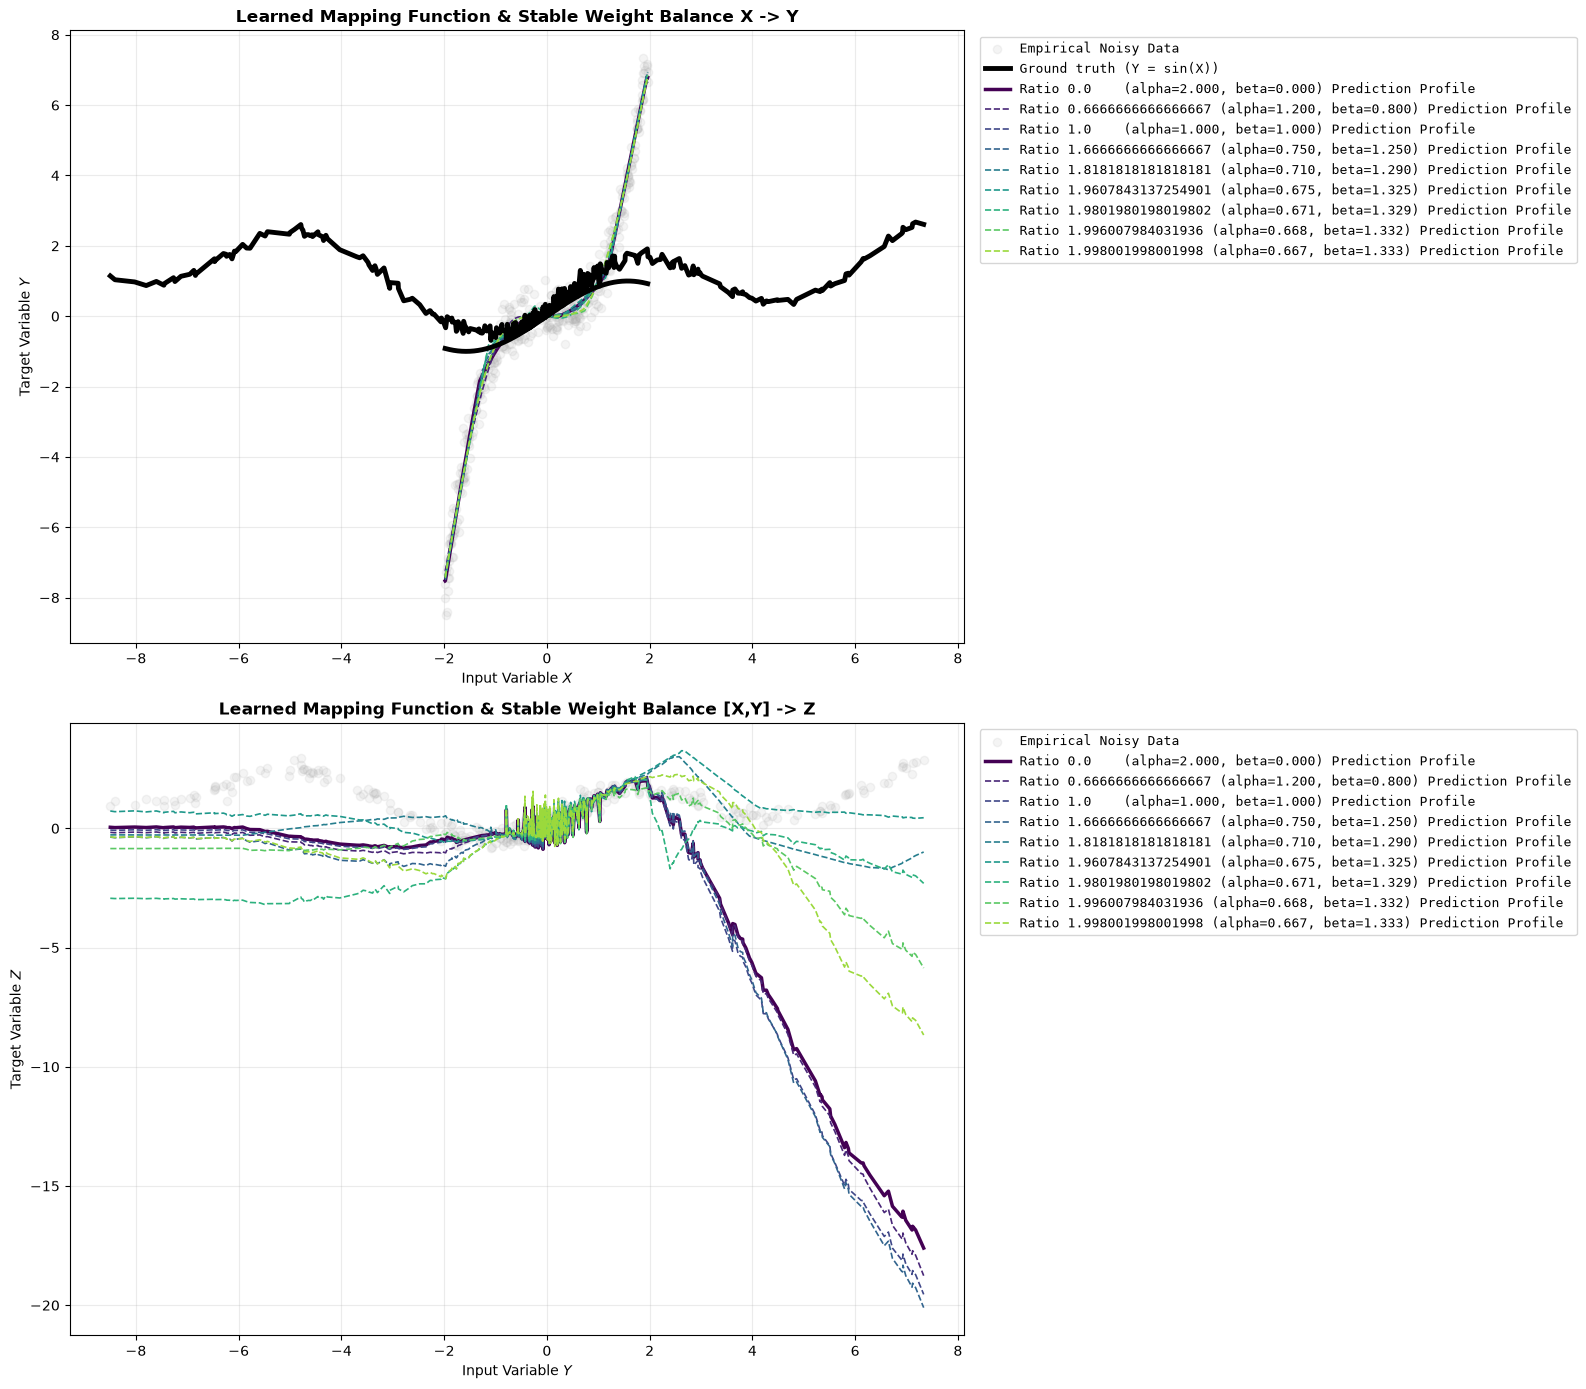

In [9]:
proportions_plot = sorted(list(trained_models.keys()))

df_sorted = df_chain.sort_values(by="Y")
x_sorted_matrix_input = df_sorted["X"].to_numpy()
y_sorted_matrix_input = df_sorted["Y"].to_numpy()
combined_sorted_input = df_sorted[["X","Y"]].to_numpy()

fig, (ax1, ax2) = plt.subplots(2,1,figsize = (16,14))

colors_gradient = plt.cm.viridis(np.linspace(0,0.85, len(proportions_plot)))

x_clean_1 = np.linspace(df_chain["X"].min(), df_chain["X"].max(), 500)
y_ground_truth_1 = np.sin(x_clean_1)

ax1.scatter(df_chain["X"], df_chain["Y"], color = 'darkgray', alpha = 0.12, label= 'Empirical Noisy Data')
ax1.plot(x_clean_1, y_ground_truth_1, color='black', linewidth = 3.5, zorder = 10,label = 'Ground truth (Y = sin(X))')

x_sorted_1 = np.sort(df_chain["X"].to_numpy())

for i, prop in enumerate(proportions_plot):
    if prop == 0:
        alpha, beta = 2.0, 0.0
    else:
        alpha = 2.0 / (1.0 + prop)
        beta = 2.0 - alpha
    
    y_pred = trained_models[prop].models["Y"].predict(x_sorted_1.reshape(-1,1)).flatten()
    
    lw = 2.5 if prop in [0.0, 1000.0] else 1.2
    ls = '-' if prop in [0.0, 1000.0] else '--'

    curve_label = f"Ratio {prop:<6} (alpha={alpha:.3f}, beta={beta:.3f}) Prediction Profile"
    ax1.plot(x_sorted_1, y_pred, color = colors_gradient[i], linestyle=ls, linewidth = lw, label=curve_label)

ax1.set_title("Learned Mapping Function & Stable Weight Balance X -> Y", fontsize = 12, fontweight ='bold')
ax1.set_xlabel("Input Variable $X$")
ax1.set_ylabel("Target Variable $Y$")
ax1.legend(bbox_to_anchor=(1.01, 1), loc = 'upper left', prop={'family': 'monospace', 'size' : 9})
ax1.grid(True, alpha=0.25)

z_ground_truth_2 = np.sin(y_sorted_matrix_input) + 0.5 * (x_sorted_matrix_input**2)
    
ax2.scatter(df_chain["Y"], df_chain["Z"], color = 'darkgray', alpha = 0.12, label= 'Empirical Noisy Data')
ax1.plot(y_sorted_matrix_input, z_ground_truth_2, color='black', linewidth = 3.5, zorder = 10,label = 'Ground truth (Z = sin(Y)+0.5X^2)')


for i, prop in enumerate(proportions_plot):
    if prop == 0:
        alpha, beta = 2.0, 0.0
    else:
        alpha = 2.0 / (1.0 + prop)
        beta = 2.0 - alpha
    
    z_pred_multivar = trained_models[prop].models["Z"].predict(combined_sorted_input).flatten()
    
    lw = 2.5 if prop in [0.0, 1000.0] else 1.2
    ls = '-' if prop in [0.0, 1000.0] else '--'

    curve_label = f"Ratio {prop:<6} (alpha={alpha:.3f}, beta={beta:.3f}) Prediction Profile"
    ax2.plot(y_sorted_matrix_input, z_pred_multivar, color = colors_gradient[i], linestyle=ls, linewidth = lw, label=curve_label)

ax2.set_title("Learned Mapping Function & Stable Weight Balance [X,Y] -> Z", fontsize = 12, fontweight ='bold')
ax2.set_xlabel("Input Variable $Y$")
ax2.set_ylabel("Target Variable $Z$")
ax2.legend(bbox_to_anchor=(1.01, 1), loc = 'upper left', prop={'family': 'monospace', 'size' : 9})
ax2.grid(True, alpha=0.25)

plots_dir = Path('plots')
plots_dir.mkdir(exist_ok = True)
output_path = plots_dir / "kan_functional_evolution_mediation_optimized.png"

plt.tight_layout()
plt.savefig(output_path, dpi = 300)
plt.show()



#4.Multi-Variate Causal Safety Evaluation

This plot display how accuracy (R^2) degradation curve against the physical structural independence profile (HSIC). This visual report reveals the "optimal trade-off point" for the chain architecture.

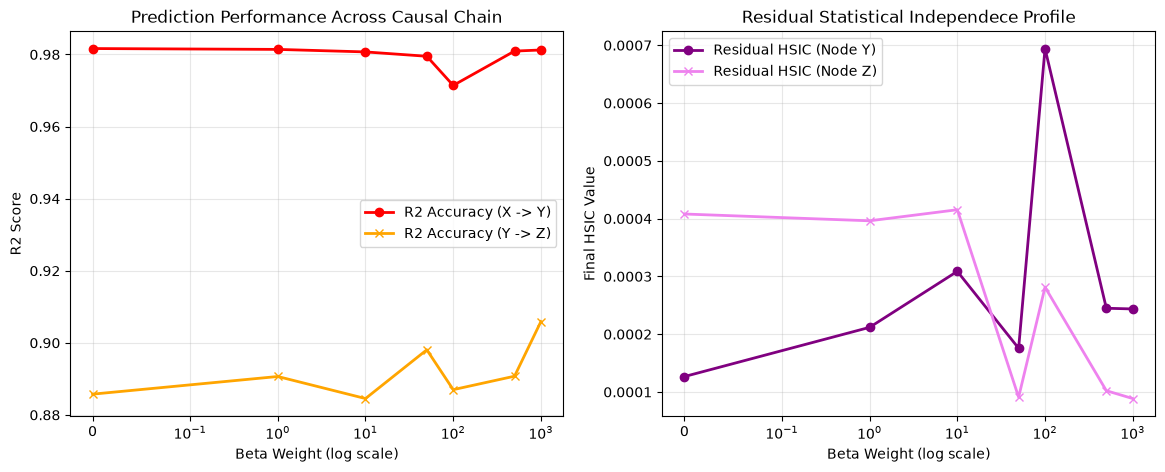

In [8]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

ax1.plot(df_res["beta"], df_res["r2_y"], marker = 'o', color='red', linewidth=2, label="R2 Accuracy (X -> Y)")
ax1.plot(df_res["beta"], df_res["r2_z"], marker = 'x', color='orange', linewidth=2, label="R2 Accuracy (Y -> Z)")
ax1.set_xscale('symlog', linthresh = 0.1)
ax1.set_title("Prediction Performance Across Causal Chain")
ax1.set_xlabel("Beta Weight (log scale)")
ax1.set_ylabel("R2 Score")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df_res["beta"], df_res["hsic_y"], marker = 'o', color='purple', linewidth=2, label="Residual HSIC (Node Y)")
ax2.plot(df_res["beta"], df_res["hsic_z"], marker = 'x', color='violet', linewidth=2, label="Residual HSIC (Node Z)")
ax2.set_xscale('symlog', linthresh = 0.1)
ax2.set_title("Residual Statistical Independece Profile")
ax2.set_xlabel("Beta Weight (log scale)")
ax2.set_ylabel("Final HSIC Value")
ax2.legend()
ax2.grid(True, alpha=0.3)



Path("plots").mkdir(exist_ok=True)
plt.savefig("plots/metrics_01_chain.png", dpi=300)
plt.show()

#4. Granular REsidual Geometry Analysis (Scatter Plot Diagnostics)

While mathematical criteria like the Hilbert-Schmidt Independence Criterion (HSIC) compress statistical dependence into a single metric, evaluating the geometric distribution of the errors provides direct visual validation.


Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu
Using device: cpu


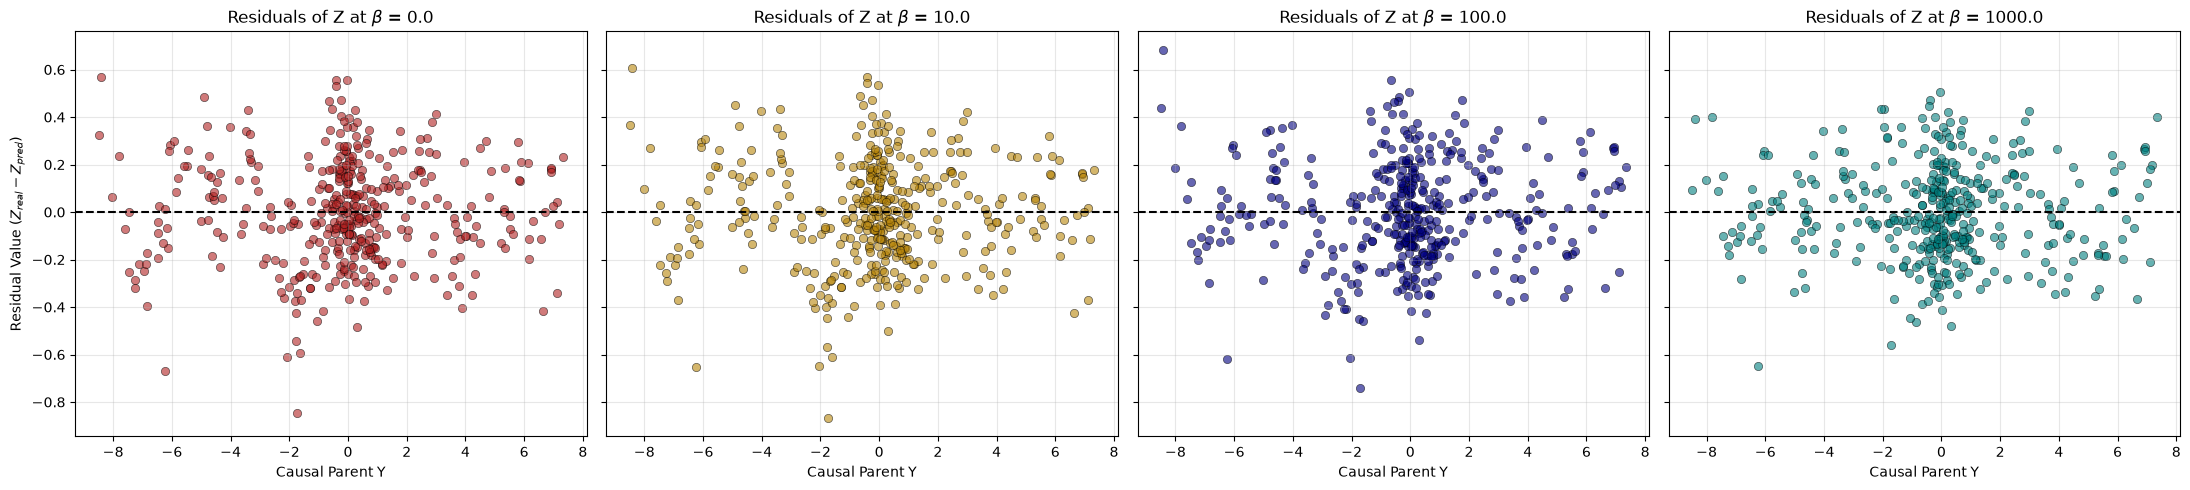

In [12]:
selected_betas = [0.0, 10.0, 100.0, 1000.0]
residual_snapshots = {}

x_np = df_chain["X"].to_numpy().copy()
y_real = df_chain["Y"].to_numpy().copy()
z_real = df_chain["Z"].to_numpy().copy()

for beta in selected_betas:
    hyperparams ={
        "hidden_dim":4,
        "batch_size": 100,
        "steps": 400,
        "lr": 0.02,
        "lamb": 0.0,
        "mult_kan": False,
        "loss": "hybrid" if beta > 0 else "mse",
        "early_stop": False,
        "verbose": 0,
        "node_types": {"X": "continuous", "Y": "continuous", "Z": "continuous"},
        "num_classes":{},
        "alpha_weight": 1.0,
        "beta_weight": beta
    }

    params = {
        "Y": deepcopy(hyperparams),
        "Z":deepcopy(hyperparams)}

    model_snapshot = kan_model_mixed(dag_chain, params)
    model_snapshot.fit(df_chain)


    z_pred = model_snapshot.models["Z"].predict(y_real.reshape(-1,1)).flatten()
    res_z = z_real - z_pred
    residual_snapshots[beta] = res_z

fig, axes = plt.subplots(1,4, figsize=(22, 5), sharey=True)
color = ['firebrick', 'darkgoldenrod', 'navy', 'teal']

for i, beta in enumerate(selected_betas):
    axes[i].scatter(y_real, residual_snapshots[beta], alpha=0.6, color=color[i], edgecolors= 'k', linewidth=0.5)
    axes[i].axhline(0,color='black', linestyle='--', linewidth=1.5)
    axes[i].set_title(f"Residuals of Z at $\\beta$ = {beta}")
    axes[i].set_xlabel("Causal Parent Y")
    if i == 0:
        axes[i].set_ylabel("Residual Value ($Z_{real} - Z_{pred}$)")
    axes[i].grid(True, alpha=0.3)

plots_dir = Path("plots")
plots_dir.mkdir(exist_ok=True)
output_path = plots_dir / "residual_diagnostic_01_granualar.png"

plt.tight_layout()
plt.savefig(output_path, dpi=300)
plt.show()


    